In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('student_exam_dataset.csv')
df.head(10)

,study_hours,exam_score,teaching_method
0,6.0,72.1,A
1,4.7,71.6,A
2,6.3,62.3,A
3,8.0,76.2,B
4,4.5,57.7,B
5,4.5,60.2,A
6,8.2,85.1,B
7,6.5,62.2,B
8,4.1,61.9,B
9,6.1,69.8,B


In [2]:
p_70 = np.mean(df['exam_score'] >= 70)
p_70

0.4083333333333333

In [7]:
cond = df[df['study_hours'] >= 5]
p_70_5 = np.mean(cond['exam_score'] >= 70)
p_70_5

0.7142857142857143

In [9]:
p_A = np.mean(df['study_hours'] >= 5)
p_B_A = p_70_5
p_B = np.mean(df['exam_score'] >= 70)
p_A_B = (p_B_A * p_A) / p_B
p_A_B

0.816326530612245

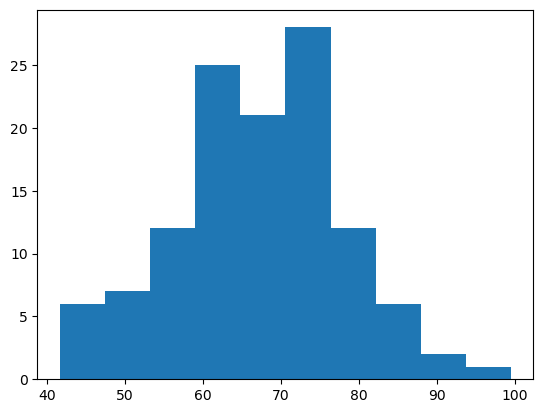

0.1369515344513754


In [11]:
plt.hist(df['exam_score'])
plt.show()

print(df['exam_score'].skew())

In [22]:
mean = df['exam_score'].mean()
median = df['exam_score'].median()
mode = df['exam_score'].mode()[0]

std = df['exam_score'].std()
var = df['exam_score'].var()
# std_var = var ** 0.5
# std_man = (mean - df['exam_score']).sum() / (len(df))

print(f'mean {mean}, median {median}, mode {mode}, std {std}, var {var}')
# std, var, std_var, std_man

mean 67.025, median 66.55, mode 71.6, std 10.947516122102652, var 119.8481092436975


In [27]:
df['exam_score'].kurtosis()

0.036324247026284784

In [35]:
n = len(df)
ci = stats.t.interval(0.95, n - 1, mean, std/np.sqrt(n))
ci

(65.04615368232368, 69.00384631767633)

In [36]:
t_st, pv = stats.ttest_1samp(df['exam_score'], 70)
t_st, pv

(-2.976884601773756, 0.0035285671318989963)

In [38]:
A = df[df['teaching_method'] == 'A']['exam_score']
B = df[df['teaching_method'] == 'B']['exam_score']

t, p = stats.ttest_ind(A, B)
t, p

(1.8322870656352859, 0.06943026247948947)